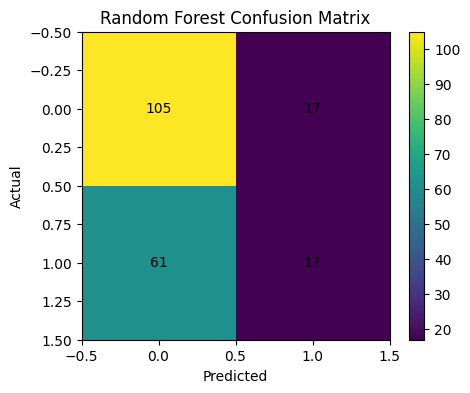

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


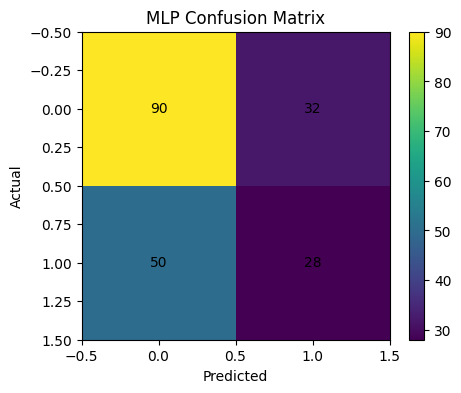

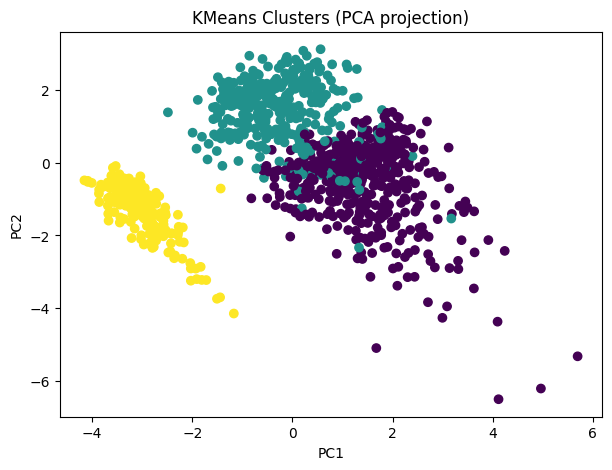

Random Forest Accuracy: 0.61
MLP Accuracy: 0.59
         tenure  MonthlyCharges  TotalCharges  churn_rate
cluster                                                  
0           8.0           51.11       383.740       0.423
1           8.0           36.53       275.445       0.364
2           7.0           29.94       191.530       0.348


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

df = pd.read_csv('customer_churn_synth.csv')

replace_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','MultipleLines']
for c in replace_cols:
    df[c] = df[c].replace({'No internet service':'No','No phone service':'No'})

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')

le = LabelEncoder()
for c in cat_cols:
    if df[c].nunique() == 2:
        df[c] = le.fit_transform(df[c])
    else:
        df = pd.get_dummies(df, columns=[c])

num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
X = df.drop(columns=['customerID','Churn'])
y = df['Churn'].map({'Yes':1,'No':0})
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf, digits=3)

plt.figure(figsize=(5,4))
plt.imshow(cm_rf, interpolation='nearest')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, str(cm_rf[i,j]), ha='center', va='center')
plt.show()

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cr_mlp = classification_report(y_test, y_pred_mlp, digits=3)

plt.figure(figsize=(5,4))
plt.imshow(cm_mlp, interpolation='nearest')
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        plt.text(j, i, str(cm_mlp[i,j]), ha='center', va='center')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title('KMeans Clusters (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

cluster_summary = df.groupby('cluster').agg({
    'tenure':'median',
    'MonthlyCharges':'median',
    'TotalCharges':'median',
    'Churn': lambda x: round((x=='Yes').mean(),3)
}).rename(columns={'Churn':'churn_rate'})
print('Random Forest Accuracy:', acc_rf)
print('MLP Accuracy:', acc_mlp)
print(cluster_summary)
